In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
from scipy.fft import fft, fftfreq
from scipy import interpolate
import scipy.integrate as integrate
from scipy.signal import find_peaks

In [98]:
signal, sr = librosa.load('/content/drive/MyDrive/musica /Sesiones_Fourier_Nota_CM_piano.mp3', sr=None)
print(f"Sample Rate: {sr}")  # Frecuencia con la que el sistema de grabación guardó los datos.
print(f"Signal Shape: {signal.shape}") #Cantidad de datos guardados

Sample Rate: 44100
Signal Shape: (152064,)


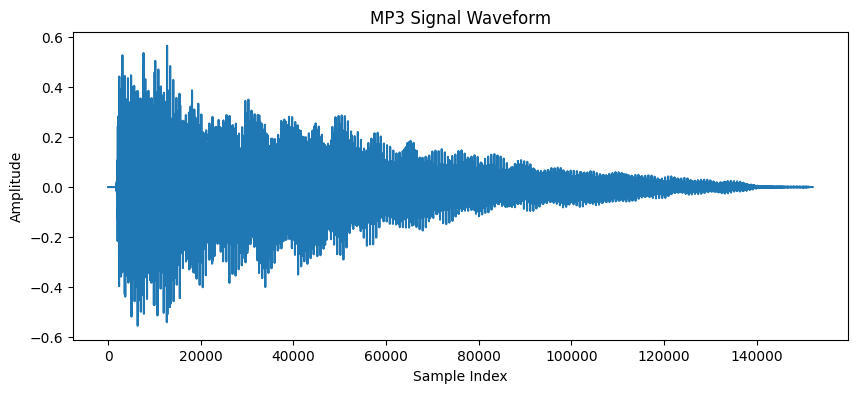

In [99]:
plt.figure(figsize=(10, 4))
plt.plot(signal)
plt.title("MP3 Signal Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

In [100]:
N = len(signal)
yf = fft(signal) #Hacer transformada de fourier rapida a la señal
xf = fftfreq(N, 1 / sr) #Lista de las frecuencias

/tmp/ipykernel_749/1488920787.py:1: RuntimeWarning: divide by zero encountered in log
  mask = (np.log(xf[:N//2]) >= 5) & (np.log(xf[:N//2]) <= 7)
/tmp/ipykernel_749/1488920787.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(xf[:N//2])[mask],(1.0/N)*np.abs(yf[:N//2])[mask])


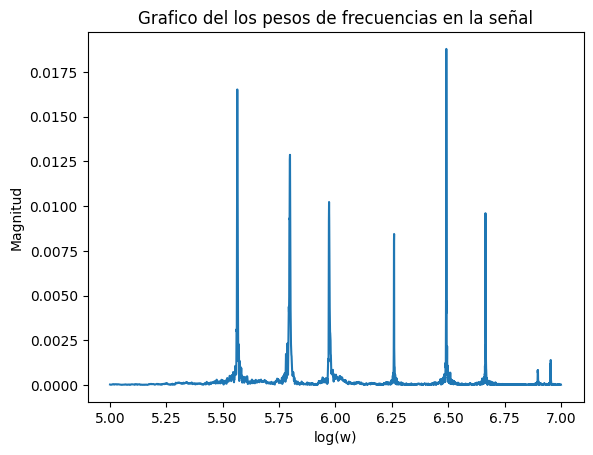

In [101]:
mask = (np.log(xf[:N//2]) >= 5) & (np.log(xf[:N//2]) <= 7)
plt.plot(np.log(xf[:N//2])[mask],(1.0/N)*np.abs(yf[:N//2])[mask])
plt.title("Grafico del los pesos de frecuencias en la señal")
plt.xlabel("log(w)")
plt.ylabel("Magnitud")
plt.show()

In [102]:
peaks, _ = find_peaks((1.0/N)*np.abs(yf[:N//2]), height=0.010)

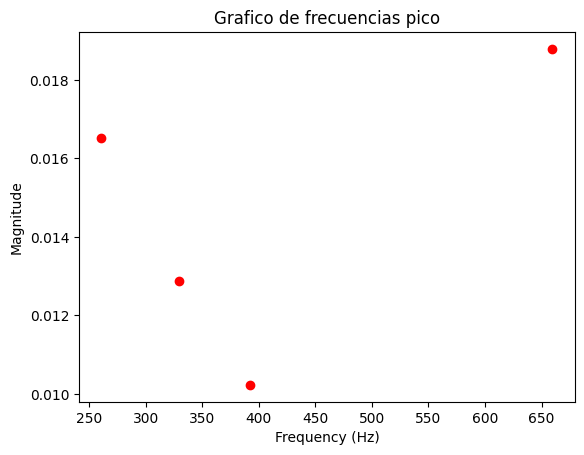

In [103]:
plt.plot(
    xf[:N//2][peaks],
    (1.0/N)*np.abs(yf[:N//2])[peaks],
    "ro"
)
plt.title("Grafico de frecuencias pico")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [104]:
xf[:N//2][peaks]

array([261.00852273, 329.74076705, 392.09280303, 659.48153409])

Al tocar el acorde, el mi de una octava más arriba resonó o fue tocado al mismo tiempo. Las frecuencias del acorde son 261.0,329.74,392.1 Hz

# Usando codigo de clase

In [105]:
def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

In [106]:
t=np.linspace(0,N/sr,N)
w= np.linspace(240,660,5000)

In [107]:
f_signal = interpolate.interp1d(
    t,
    signal,
    kind="linear",
    bounds_error=False,
    fill_value=0
)

In [108]:
df = []
for i in range(len(w)):
    ARew = integrate.quad(lambda tau: f_signal(tau)*g(tau,w[i]).real, t.min(), t.max())[0]
    AImw = integrate.quad(lambda tau: f_signal(tau)*g(tau,w[i]).imag, t.min(), t.max())[0]
    AMP = np.sqrt(ARew**2 + AImw**2)
    ANG = np.arctan2(AImw, ARew)
    df.append([w[i], ARew, AImw, AMP, ANG])
df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])

/tmp/ipykernel_749/3913549642.py:3: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  ARew = integrate.quad(lambda tau: f_signal(tau)*g(tau,w[i]).real, t.min(), t.max())[0]
/tmp/ipykernel_749/3913549642.py:4: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(lambda tau: f_signal(tau)*g(tau,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_749/3913549642.py:3: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(lambda tau: f_signal(tau)*g(tau,w[i]).real, t.min(), t.max())[0]
/tmp/ipykern

<function matplotlib.pyplot.show(close=None, block=None)>

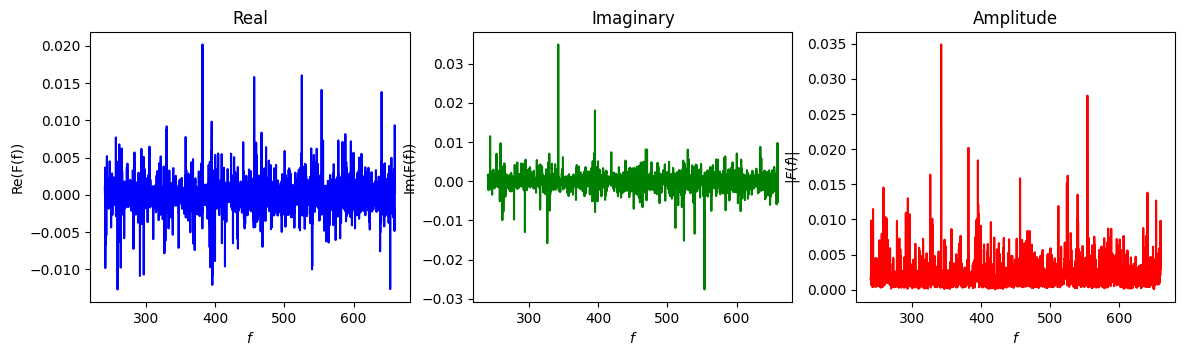

In [109]:
plt.figure(figsize=(14,3.5))
######## REAL ###########
plt.subplot(1,3,1)
plt.plot(df.w, df.ReTw,'b-')
plt.title('Real')
plt.xlabel('$f$')
plt.ylabel('Re(F(f))')
######### IMAG ##########
plt.subplot(1,3,2)
plt.plot(df.w, df.ImTw,'g-')
plt.title('Imaginary')
plt.xlabel('$f$')
plt.ylabel('Im(F(f))')
######### AMP ###########
plt.subplot(1,3,3)
plt.plot(df.w, df.AMP,'r-')
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('$|F(f)|$')
plt.show

In [110]:
peaks, _ =find_peaks(
    df.AMP,
    height=0.02
)


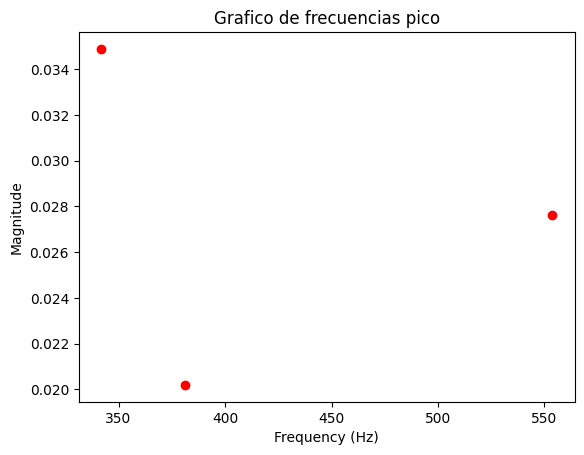

In [111]:
plt.plot(
    df.w[peaks],
    df.AMP[peaks],
    "ro"
)
plt.title("Grafico de frecuencias pico")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [112]:
print(f"Las frecuencias que produgeron picos con el codigo de clase son ")
print(df.w[peaks])

Las frecuencias que produgeron picos con el codigo de clase son 
1213    341.912382
1682    381.316263
3733    553.634727
Name: w, dtype: float64


In [113]:
print("la diferancia con las encontradas usando el codigo de numpy son")
xf[:N//2][peaks] - np.array(df.w[peaks])

la diferancia con las encontradas usando el codigo de numpy son


array([  9.86910427, 106.47966478, 528.97062343])

Se puede ver como los picos tiene una erro alto respecto a los valores reales dado que se tomas pocos datos pero funcionan